# About BERT

Based on Nika Zykova's handout

In [1]:
!pip install datasets transformers tokenizers evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


## A bit of theory

Important dates:
- 2013 - Word2Vec
- 2017 - "Attention is all you need" [1]
- 2018 - 2019 - BERT [2]
- 2022 - LLMs

BERT:
- contextual embeddings
- attention mechanism

BERT is trained on two tasks:
- Masked Language Modelling (MLM)
- Next Sentence Prediction (NSP)

Other transformers are often trained on  Causal Language Modelling (CLM) - next token prediction

__Attention mechanisms__

[The source of the illustrations](https://jalammar.github.io/illustrated-transformer/)

<img src='https://jalammar.github.io/images/t/transformer_self-attention_visualization.png'>

- A part of the model that provides each token with a corresponding vector that encodes the importance of other words in the sentence
- The vector is the result of the multiplication of three matrices: queries, keys and values

__The transformer__


<img src='https://jalammar.github.io/images/t/The_transformer_encoders_decoders.png'>

- BERT - is just an encoder, GPT is just a decoder. In an encoder the attention is directed at the whole sentence, since an encoder needs to transform it into an embedding. In a decoder the attention is directed just at the preceding tokens, since it is geared towards generation.

|Encoder|Decoder|Encoder-Decoder|
|--|--|--|
|BERT|GPT|T5|
|RoBERTa|Qwen|Bart|
|ALBERT|DeepSeek|Pegasus|
|ELECTRA|LLaMA|ProphetNet|




References:
1. Vaswani A. et al. Attention is all you need //Advances in neural information processing systems. – 2017. – Т. 30.
2. Devlin J. et al. BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding //Proceedings of NAACL-HLT. – 2019. – С. 4171-4186.

[How a transformer works](https://habr.com/ru/articles/486358/)

[How a transformer works -- in English](https://jalammar.github.io/illustrated-transformer/)

## Hugging Face

[Hugging Face](https://huggingface.co/):

- datasets
- models trained on those datasets
- python libraries to work with those models

## Datasets

In [2]:
from datasets import load_dataset

Loading the whole dataset:

In [3]:
dataset = load_dataset("blinoff/kinopoisk")

README.md:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

kinopoisk.jsonl: reconstructing file:   0%|          |  0.00B /  143MB            

kinopoisk.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/36591 [00:00<?, ? examples/s]

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content'],
        num_rows: 36591
    })
})

Loading a part of a dataset:

In [5]:
small_dataset = load_dataset("blinoff/kinopoisk", split='train[10:20]')

In [6]:
small_dataset

Dataset({
    features: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content'],
    num_rows: 10
})

In [7]:
dataset['train'][1:3]

{'part': ['top250', 'top250'],
 'movie_name': ['Блеф (1976)', 'Блеф (1976)'],
 'review_id': ['17139', '17137'],
 'author': ['Stasiki', 'Flashman'],
 'date': [datetime.datetime(2008, 3, 4, 0, 0),
  datetime.datetime(2007, 3, 4, 0, 0)],
 'title': [None, None],
 'grade3': ['Good', 'Good'],
 'grade10': ['0', '10'],
 'content': ['\nАдриано Челентано продолжает радовать нас\xa0своими работами в\xa0жизни кино и\xa0в сфере музыкального творчества. Новая захватывающая, интересная и\xa0талантливо исполненная история покажет, какие бывают денежные махинации в\xa0мире, чего стоит связаться с\xa0оригинальным, находчивым человеком, которого зовут Феникс, как\xa0заполучить приличную денежную сумму, чтобы жить всю\xa0оставшуюся жизнь в\xa0роскоши и\xa0в свое удовольствие.\n\nБлестяще смешной фильм, рассчитанный на\xa0широкую аудиторию, комедия, от\xa0которой получаешь наслаждение, где\xa0проникаешься игрой актеров и\xa0чувствуешь их\xa0азартный вкус на\xa0вещи, когда хочется лечь на\xa0кровать, не\xa0

To get a smaller dataset, use `select`

In [8]:
dataset['train'].select([1, 2])

Dataset({
    features: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content'],
    num_rows: 2
})

`filter` to get a part of a dataset based on a condition

In [9]:
dataset.filter(lambda item: float(item['grade10']) > 9)

Filter:   0%|          | 0/36591 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content'],
        num_rows: 13487
    })
})

To split a dataset:

In [10]:
dataset['train'].train_test_split(test_size=0.1)

DatasetDict({
    train: Dataset({
        features: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content'],
        num_rows: 32931
    })
    test: Dataset({
        features: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content'],
        num_rows: 3660
    })
})

## Tokenizer

In [11]:
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [12]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [13]:
tokenizer.tokenize('Что ты здесь делаешь?')

['Что', 'ты', 'здесь', 'дела', '##ешь', '?']

In [14]:
tokenizer.encode('Что ты здесь делаешь?')

[101, 13302, 4609, 10378, 11725, 26318, 166, 102]

In [15]:
tokenizer.decode(tokenizer.encode('Что ты здесь делаешь?'))

'[CLS] Что ты здесь делаешь? [SEP]'

In [ ]:
tokenizer('Что ты здесь делаешь?')

- `return_tensors` - to set the return datatype: `tf` (`tensorflow`), `pt` (`pytorch`) and  `np` (`numpy`). If not set, returns lists
- `padding` - to set padding to the input
- `truncation` - to truncate the sequence
- `max_length` - to set the maximal length of a sequence


In [16]:
text1 = 'Что ты здесь делаешь?'
text2 = 'Сижу на дереве.'

In [17]:
tokenizer(text1, return_tensors='pt', max_length=16)

{'input_ids': tensor([[  101, 13302,  4609, 10378, 11725, 26318,   166,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [18]:
tokenizer(text1, padding='max_length', truncation=True, return_tensors='pt',
          max_length=16)

{'input_ids': tensor([[  101, 13302,  4609, 10378, 11725, 26318,   166,   102,     0,     0,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])}

Tokenizer can work with a pair of texts:

In [19]:
tokenizer(text1, text2, padding='max_length', truncation=True, return_tensors='pt',
          max_length=16)

{'input_ids': tensor([[  101, 13302,  4609, 10378, 11725, 26318,   166,   102, 18764, 17847,
          1469, 62140,   132,   102,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]])}

In [20]:
tokenizer.decode(tokenizer.encode(text1, text2))

'[CLS] Что ты здесь делаешь? [SEP] Сижу на дереве. [SEP]'

In [21]:
tokenizer([text1, text2], padding='max_length', truncation=True, return_tensors='pt',
          max_length=16)

{'input_ids': tensor([[  101, 13302,  4609, 10378, 11725, 26318,   166,   102,     0,     0,
             0,     0,     0,     0,     0,     0],
        [  101, 18764, 17847,  1469, 62140,   132,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}

## Model

As with the tokenizer, with the model, you need to load it:

In [22]:
model = AutoModel.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    attn_implementation="eager" # if you want to extract attention matrices
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  714MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


What does it consist of?

In [23]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

Let's now look at how to use all this:
1. First we need to tokenize the sequence
2. Then we give the result to the model

In [24]:
toks = tokenizer(text1, padding='max_length', truncation=True, return_tensors='pt',
          max_length=16)
with torch.no_grad():
    model_output = model(**{k: v.to(model.device) for k, v in toks.items()},
                         output_attentions=True,
                         output_hidden_states=True)

In [25]:
model.embeddings.word_embeddings(toks['input_ids'])

tensor([[[-0.0157,  0.0058,  0.0008,  ...,  0.0132, -0.0251, -0.0011],
         [-0.0389,  0.0253,  0.0235,  ...,  0.0025, -0.0004, -0.0316],
         [ 0.0031,  0.0281, -0.0719,  ..., -0.0359, -0.0867,  0.0383],
         ...,
         [ 0.0041,  0.0138, -0.0080,  ...,  0.0170,  0.0175,  0.0226],
         [ 0.0041,  0.0138, -0.0080,  ...,  0.0170,  0.0175,  0.0226],
         [ 0.0041,  0.0138, -0.0080,  ...,  0.0170,  0.0175,  0.0226]]],
       grad_fn=<EmbeddingBackward0>)

Let's look at the model output

In [26]:
type(model_output)

transformers.modeling_outputs.BaseModelOutputWithPoolingAndCrossAttentions

In [27]:
model_output.keys()

odict_keys(['last_hidden_state', 'pooler_output', 'hidden_states', 'attentions', 'cross_attentions'])

In [28]:
model_output.last_hidden_state, model_output.last_hidden_state.shape

(tensor([[[-0.2554,  0.0835,  0.0891,  ...,  0.1840, -0.2018, -0.1841],
          [-0.6411, -0.1555,  0.1629,  ...,  0.8837, -0.4442, -0.1713],
          [-0.2816, -0.3796,  0.4058,  ...,  0.8235, -0.5796,  0.1911],
          ...,
          [-0.5254, -0.1365,  0.4963,  ...,  0.5846, -0.3498, -0.5520],
          [-0.5123, -0.1249,  0.4290,  ...,  0.5830, -0.4738, -0.5583],
          [-0.6484, -0.2304,  0.5001,  ...,  0.6024, -0.4024, -0.5491]]]),
 torch.Size([1, 16, 768]))

In [29]:
model_output.hidden_states[1], model_output.hidden_states[0].shape, len(model_output.hidden_states)

(tensor([[[ 0.5048,  0.1821,  0.2711,  ..., -0.2193, -0.4851,  0.3682],
          [-1.2503,  0.2730,  0.8037,  ...,  1.0978, -0.5753, -1.0308],
          [ 0.4937,  0.1345, -1.3058,  ..., -0.0158, -2.2283,  1.2935],
          ...,
          [ 0.2993,  0.2103,  0.2959,  ..., -0.1225,  0.0124,  0.4592],
          [ 0.3090,  0.1888,  0.4228,  ..., -0.1918, -0.0438,  0.4677],
          [ 0.3571,  0.0330,  0.3362,  ..., -0.1648, -0.0997,  0.3207]]]),
 torch.Size([1, 16, 768]),
 13)

Let's look at the attention matrices:

In [30]:
model_output.attentions[0], model_output.attentions[0].shape, len(model_output.attentions)

(tensor([[[[0.3414, 0.0504, 0.0379,  ..., 0.0000, 0.0000, 0.0000],
           [0.0587, 0.0799, 0.0616,  ..., 0.0000, 0.0000, 0.0000],
           [0.1285, 0.0691, 0.2221,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.1626, 0.1345, 0.0596,  ..., 0.0000, 0.0000, 0.0000],
           [0.1668, 0.1220, 0.0558,  ..., 0.0000, 0.0000, 0.0000],
           [0.1547, 0.1348, 0.0473,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.2794, 0.0937, 0.0398,  ..., 0.0000, 0.0000, 0.0000],
           [0.0940, 0.1348, 0.1076,  ..., 0.0000, 0.0000, 0.0000],
           [0.0118, 0.2121, 0.1965,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.1929, 0.0338, 0.0768,  ..., 0.0000, 0.0000, 0.0000],
           [0.1468, 0.0317, 0.0794,  ..., 0.0000, 0.0000, 0.0000],
           [0.1436, 0.0402, 0.0881,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.1824, 0.0579, 0.1549,  ..., 0.0000, 0.0000, 0.0000],
           [0.0422, 0.1223, 0.1653,  ..., 0.0000, 0.0000, 0.0000],
           [0.1017, 0.14

In [31]:
mask_example = toks["attention_mask"][0].bool()
attn_mean = torch.mean(model_output.attentions[0], dim=1).squeeze()
attn_masked = attn_mean[mask_example][:, mask_example]

tokens = tokenizer.convert_ids_to_tokens(toks["input_ids"][0])
tokens = [t for t, m in zip(tokens, toks["attention_mask"][0]) if m]

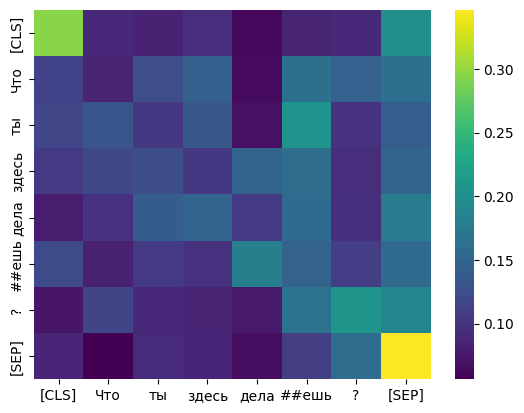

In [32]:
sns.heatmap(attn_masked, xticklabels=tokens, yticklabels=tokens, cmap="viridis");

In colab you can speed up the process by using the video card:

In [33]:
torch.cuda.is_available()

True

In [34]:
device_cuda = torch.device("cuda")
device_cpu = torch.device("cpu")

In [35]:
texts = list(dataset['train'].select(range(2))['content'])
toks = tokenizer(texts, padding='max_length', truncation=True, return_tensors='pt',
    max_length=256)

In [36]:
model = model.to(device_cpu)

In [37]:
%%timeit
with torch.no_grad():
    model_output = model(**{k: v.to(model.device) for k, v in toks.items()})

2.18 s ± 660 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [38]:
model = model.to(device_cuda)

In [39]:
%%timeit
with torch.no_grad():
    model_output = model(**{k: v.to(model.device) for k, v in toks.items()})

32.2 ms ± 11.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Training

Now let's predict the tonality of the review:

In [40]:
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
import evaluate
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Let's load the dataset. We'll leave just 1000 lines.

In [41]:
dataset = load_dataset("blinoff/kinopoisk")
dataset = dataset['train'].select(range(1000))

Let's tokenize the dataset (only for small datasets):

In [42]:
def tokenize(example):
    return tokenizer(
        example["content"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Useful preprocessing:
- changing the review score to label;
- changing the label data format from string to float;
- getting rid of the content column;
- setting the datatype for the columns;
- splitting the dataset into train and test.


In [43]:
def convert_label(example):
    example["label"] = float(example["label"])
    return example

dataset = dataset.rename_column("grade10", "label")
dataset = dataset.map(convert_label)
dataset = dataset.remove_columns(["content"])

dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "label"]
)

dataset = dataset.train_test_split(test_size=0.1, seed=42)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading the model again, now as the base for regression analysis. If you change `model.config.problem_type = "regression"` to `num_labels=` with the number of desired classes, you can solve the classification problem.

In [44]:
model = AutoModelForSequenceClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=1
)
model.config.problem_type = "regression"

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

Defining the metrics (the commented out version will work for earlier versions of evaluate):

In [ ]:
# rmse = evaluate.load("rmse")
# mae = evaluate.load("mae")
# r2 = evaluate.load("r2")

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     # regression logits.shape = (batch_size,1)
#     preds = logits.squeeze(-1)  # (batch_size,)
#     return {
#         "rmse": rmse.compute(predictions=preds, references=labels)["rmse"],
#         "mae": mae.compute(predictions=preds, references=labels)["mae"],
#         "r2": r2.compute(predictions=preds, references=labels)["r2"]
#     }

In [45]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.squeeze(-1)  # (batch_size,)

    mse = mean_squared_error(labels, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

Training parameters:

In [46]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    save_total_limit=1
)

In [47]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
)

Training and evaluating:

In [48]:
trainer.train()

Epoch,Training Loss,Validation Loss,Rmse,Mae,R2
1,No log,30.770342,5.547103,5.254884,-0.504155
2,No log,24.812489,4.981214,4.859985,-0.212915
3,No log,23.544069,4.852224,4.748095,-0.150911


TrainOutput(global_step=45, training_loss=40.732028537326386, metrics={'train_runtime': 121.6962, 'train_samples_per_second': 22.186, 'train_steps_per_second': 0.37, 'total_flos': 355196735539200.0, 'train_loss': 40.732028537326386, 'epoch': 3.0})

In [49]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Rmse,Mae,R2
No log,23.544069,3,4.852224,4.748095,-0.150911


{'eval_loss': 23.544069290161133,
 'eval_rmse': 4.852223521732938,
 'eval_mae': 4.7480950355529785,
 'eval_r2': -0.15091097354888916}